## FDSN

## Índice
1. [ Recuperación de Datos de Centros de Datos ](#1-recuperación)
2. [Forma de onda](#2-forma-de-onda)
3. [Obtener eventos](#3-eventos)
4. [Obtener estaciones](#4-estaciones)
5. [Enrutamiento](#5-enrutamiento)
6. [Descargador masivo FDSN](#6-descargador-masivo)
7. [Servicios web de IRIS](#7-iris)
8. [Servidor de Formas de Onda Earthworm](#8-earthworm)

### 1. Recuperación de Datos de Centros de Datos <a id="1-recuperación"></a>
El caso de uso más común suele ser descargar formas de onda e información meta sobre eventos y estaciones. En casi todos los casos, querrás usar el módulo `obspy.clients.fdsn` para esto. Es compatible con la mayor cantidad de centros de datos y utiliza los formatos más modernos. Aún hay razones para elegir otro módulo, pero asegúrate de tener una justificación válida.

**Tipos de Datos Disponibles**  

 | Tipo de Dato         | Formato                     |
 |----------------------     |----------------------------|
 | Formas de onda            | MiniSEED (y otros opcionales) |
 | Información de estaciones | StationXML y texto       |
 | Información de eventos | QuakeML y texto           |
 
Si necesitas solicitar formas de onda o metadatos de estaciones/eventos, lo más probable es que quieras usar el módulo `obspy.clients.fdsn`. Puede solicitar datos de cualquier centro que implemente los servicios web FDSN.

In [1]:
import obspy
from obspy.clients.fdsn import Client

In [2]:
# Crear cliente para IRIS
client = Client("IRIS")

In [3]:
# Obtener información de una estación
inventory = client.get_stations(network="IU", station="ANMO", level="response")
print(inventory)

Inventory created at 2025-05-06T03:00:31.323000Z
	Created by: IRIS WEB SERVICE: fdsnws-station | version: 1.1.52
		    http://service.iris.edu/fdsnws/station/1/query?network=IU&station=A...
	Sending institution: IRIS-DMC (IRIS-DMC)
	Contains:
		Networks (1):
			IU
		Stations (3):
			IU.ANMO (Albuquerque, New Mexico, USA) (3x)
		Channels (724):
			IU.ANMO..BC0 (3x), IU.ANMO..BC1 (3x), IU.ANMO..BCI (3x), 
			IU.ANMO..BHZ (6x), IU.ANMO..BHN (6x), IU.ANMO..BHE (6x), 
			IU.ANMO..BH1 (4x), IU.ANMO..BH2 (4x), IU.ANMO..BHU (2x), 
			IU.ANMO..BHV (2x), IU.ANMO..BHW (2x), IU.ANMO..EHZ (5x), 
			IU.ANMO..EHN (5x), IU.ANMO..EHE (5x), IU.ANMO..HHZ, IU.ANMO..HH1, 
			IU.ANMO..HH2, IU.ANMO..HHU (3x), IU.ANMO..HHV (3x), 
			IU.ANMO..HHW (3x), IU.ANMO..LCI (2x), IU.ANMO..LD2 (2x), 
			IU.ANMO..LDI (3x), IU.ANMO..LFZ (4x), IU.ANMO..LHZ (6x), 
			IU.ANMO..LHN (6x), IU.ANMO..LHE (6x), IU.ANMO..LH1 (4x), 
			IU.ANMO..LH2 (4x), IU.ANMO..LHU (2x), IU.ANMO..LHV (2x), 
			IU.ANMO..LHW (2x), IU.ANMO..LWS (4x),

### 2. Forma de onda (`get_waveforms`) <a id="2-forma-de-onda"></a>

El siguiente ejemplo muestra cómo solicitar y graficar 60 minutos del canal `LHZ` de la estación Albuquerque, Nuevo México (`ANMO`), perteneciente a la Red Sísmica Global (`IU`), para un evento sísmico ocurrido alrededor del 2010-02-27 06:45 (UTC).

In [4]:
from obspy import UTCDateTime

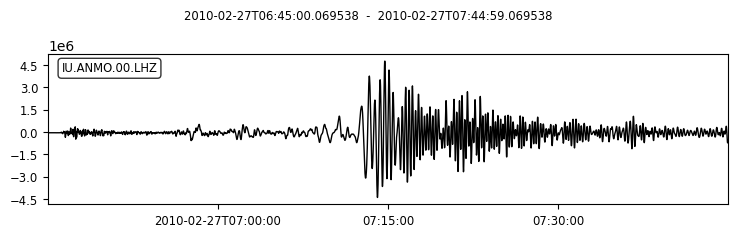

In [6]:
t = UTCDateTime("2010-02-27T06:45:00.000")
st = client.get_waveforms("IU", "ANMO", "00", "LHZ", t, t + 60 * 60)
st.plot();  

### 3. Obtener eventos (`get_events`) <a id="3-eventos"></a>

In [7]:
starttime = UTCDateTime("2002-01-01")
endtime = UTCDateTime("2002-01-02")
cat = client.get_events(starttime=starttime, endtime=endtime,
                        minmagnitude=6, catalog="ISC")
print(cat)  

2 Event(s) in Catalog:
2002-01-01T11:29:22.720000Z |  +6.282, +125.749 | 6.3  MW
2002-01-01T07:28:57.480000Z | +36.991,  +72.336 | 6.3  Mb


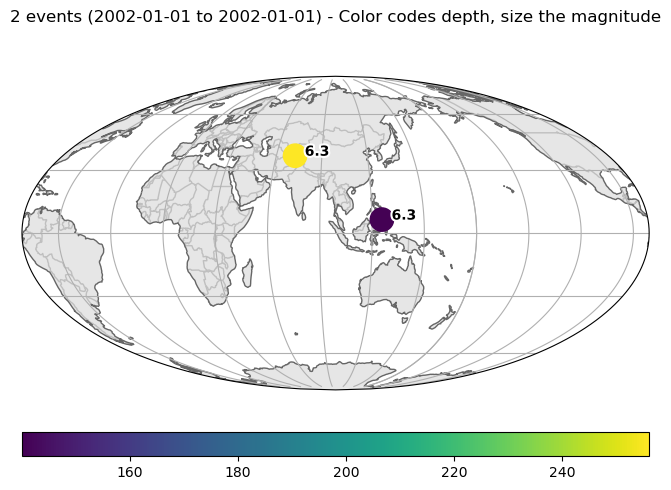

In [8]:
cat.plot();  

### 4. Obtener estaciones (`get_stations`) <a id="4-estaciones"></a>

In [9]:
inventory = client.get_stations(network="IU", station="A*",
                                starttime=starttime,
                                endtime=endtime)
print(inventory)  

Inventory created at 2025-05-06T03:05:23.714900Z
	Created by: IRIS WEB SERVICE: fdsnws-station | version: 1.1.52
		    http://service.iris.edu/fdsnws/station/1/query?starttime=2002-01-...
	Sending institution: IRIS-DMC (IRIS-DMC)
	Contains:
		Networks (1):
			IU
		Stations (3):
			IU.ADK (Adak, Aleutian Islands, Alaska)
			IU.AFI (Afiamalu, Samoa)
			IU.ANMO (Albuquerque, New Mexico, USA)
		Channels (0):



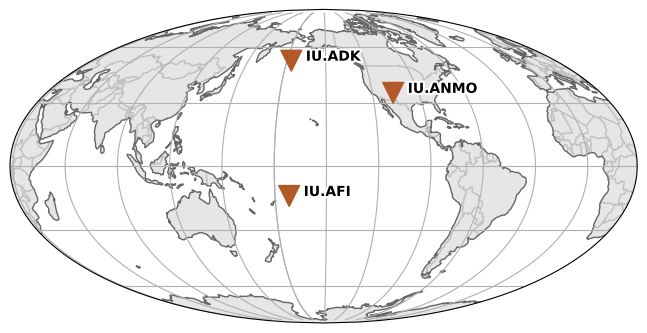

In [10]:
inventory.plot();

### 5. Enrutamiento <a id="5-enrutamiento"></a>

Si no sabes qué centro de datos tiene qué información, puedes usar un servicio de enrutamiento. ObsPy es compatible con dos:

 1. **El Federador de IRIS**  
 2. **El Servicio de Enrutamiento EIDAWS**  

In [11]:
from obspy.clients.fdsn import RoutingClient

In [12]:
client = RoutingClient("iris-federator")
print(type(client))  

<class 'obspy.clients.fdsn.routing.federator_routing_client.FederatorRoutingClient'>


In [13]:
client = RoutingClient("eida-routing")
print(type(client))  

<class 'obspy.clients.fdsn.routing.eidaws_routing_client.EIDAWSRoutingClient'>


Para realizar consultas de formas de onda con restricciones geográficas mediante el servicio EIDA, ObsPy ejecuta automáticamente una consulta previa de estaciones antes de descargar los datos. Esto garantiza una experiencia de usuario similar entre los servicios de enrutamiento de EIDA e IRIS.

El siguiente fragmento utiliza el IRIS federator para identificar qué centros de datos contienen la información solicitada y luego descarga los datos directamente de cada fuente. Todo el proceso es automático.

In [14]:
client = RoutingClient("iris-federator")
st = client.get_waveforms(
    channel="LHZ", starttime=UTCDateTime(2017, 1, 1),
    endtime=UTCDateTime(2017, 1, 1, 0, 5), latitude=10,
    longitude=10, maxradius=25)  
print(st)  

2 Trace(s) in Stream:
II.MBAR.00.LHZ | 2017-01-01T00:00:00.069538Z - 2017-01-01T00:04:59.069538Z | 1.0 Hz, 300 samples
II.MBAR.10.LHZ | 2017-01-01T00:00:00.069538Z - 2017-01-01T00:04:59.069538Z | 1.0 Hz, 300 samples


Lo mismo funciona para las estaciones.

In [15]:
client = RoutingClient("iris-federator")
inv = client.get_stations(
    channel="LHZ", starttime=UTCDateTime(2017, 1, 1),
    endtime=UTCDateTime(2017, 1, 1, 0, 5), latitude=10,
    level="channel", longitude=10, maxradius=25)  
print(inv)  

Inventory created at 2025-05-06T03:11:06.747400Z
	Created by: ObsPy 1.4.1
		    https://www.obspy.org
	Sending institution: IRIS-DMC,ObsPy FDSN Routing 1.4.1,RESIF-SI,SeisComP (GFZ,IRIS-DMC,RESIF-DC)
	Contains:
		Networks (5):
			AF, G, II, IU, TT
		Stations (6):
			AF.EKNA (Ekona, Cameroon)
			AF.KIG (Kigali, Rwanda)
			G.TAM (Tamanrasset, Algeria)
			II.MBAR (Mbarara, Uganda)
			IU.KOWA (Kowa, Mali)
			TT.TATN (Station Tataouine, Tunisia)
		Channels (7):
			AF.EKNA..LHZ, AF.KIG..LHZ, G.TAM.00.LHZ, II.MBAR.00.LHZ, 
			II.MBAR.10.LHZ, IU.KOWA.00.LHZ, TT.TATN.00.LHZ


### 6. Descargador Masivo FDSN <a id="6-descargador-masivo"></a>
Si necesitas descargar grandes cantidades de datos de múltiples centros, el descargador masivo (o por lotes) de ObsPy es para ti.

In [4]:
# Ejemplo Este código prepara (pero no ejecuta) una descarga masiva de datos sísmicos para:
# Un día completo (1-2 enero 2020).
# Segmentado en bloques de 24 horas para mayor eficiencia.
from obspy.clients.fdsn.mass_downloader import RectangularDomain, Restrictions, MassDownloader

In [5]:
# Definir área geográfica
domain = RectangularDomain(minlatitude=-5, maxlatitude=5,
                          minlongitude=-80, maxlongitude=-70)

In [8]:
# Configurar restricciones
restrictions = Restrictions(
    starttime=obspy.UTCDateTime(2020, 1, 1),
    endtime=obspy.UTCDateTime(2020, 1, 2),
    chunklength_in_sec=86400)

### 7. Servicios Web de IRIS <a id="7-iris"></a>
**Tipos de Datos y Formatos Disponibles:** 

 | Servicio Web de IRIS                     | Función/Modulo Equivalente en ObsPy         |
 |-----------------------------------------|--------------------------------------------|
 | `Client.traveltime()`                   | `obspy.taup`                               |
 | `Client.distaz()`                       | `obspy.geodetics`                          |
 | `Client.flinnengdahl()`                 | `obspy.geodetics.flinnengdahl.FlinnEngdahl`|
 

In [9]:
# Ejemplo de uso de Taup en lugar de IRIS
from obspy.taup import TauPyModel

In [10]:
model = TauPyModel(model="ak135")
arrivals = model.get_travel_times(source_depth_in_km=10,
                                distance_in_degree=45)
print(arrivals)

33 arrivals
	P phase arrival at 495.527 seconds
	pP phase arrival at 498.663 seconds
	sP phase arrival at 499.895 seconds
	PcP phase arrival at 596.527 seconds
	PP phase arrival at 600.636 seconds
	PP phase arrival at 603.604 seconds
	PP phase arrival at 606.093 seconds
	ScP phase arrival at 829.033 seconds
	PcS phase arrival at 830.215 seconds
	S phase arrival at 894.009 seconds
	pS phase arrival at 897.716 seconds
	sS phase arrival at 899.168 seconds
	SP phase arrival at 900.910 seconds
	PS phase arrival at 902.367 seconds
	PKiKP phase arrival at 1015.201 seconds
	pPKiKP phase arrival at 1018.645 seconds
	sPKiKP phase arrival at 1019.812 seconds
	ScS phase arrival at 1092.932 seconds
	SS phase arrival at 1095.701 seconds
	SS phase arrival at 1096.907 seconds
	SS phase arrival at 1103.605 seconds
	SS phase arrival at 1111.322 seconds
	SS phase arrival at 1111.372 seconds
	SS phase arrival at 1120.650 seconds
	SS phase arrival at 1120.964 seconds
	SKiKP phase arrival at 1227.254 second

### 8. Servidor de Formas de Onda Earthworm <a id="8-earthworm"></a>

 **Tipos de Datos Disponibles**  
 
 | Tipo de Dato         | Formato          |
 |----------------------|-----------------|
 | Formas de onda       | Formato personalizado |


### NEIC

 **Tipos de Datos Disponibles**  
 
 | Tipo de Dato         | Formato   |
 |----------------------|----------|
 | Formas de onda       | MiniSEED |


### SeedLink

 **Tipos de Datos Disponibles**  
 
 | Tipo de Dato         | Formato   |
 |----------------------|----------|
 | Formas de onda       | MiniSEED |


### Servicio Syngine

 **Tipos de Datos Disponibles**  
 
 | Tipo de Dato         | Formato                     |
 |----------------------|----------------------------|
 | Formas de onda       | MiniSEED y archivos SAC comprimidos |

**Referencias**

obspy.clients.fdsn - FDSN web service client for ObsPy — ObsPy 1.4.2 documentation. (n.d.). Obspy.org. Recuperado de https://docs.obspy.org/packages/obspy.clients.fdsn.html

Retrieving Data from Data Centers — ObsPy 1.4.2 documentation. (n.d.). Obspy.org. Recuperado de https://docs.obspy.org/tutorial/code_snippets/retrieving_data_from_datacenters.html